# Exploring DEGURBA thresholds on the CRCM6 (NA-CORDEX) domain

We regridded GHS-SMOD E2025 (R2023A V2.0, Mollweide 1 km) onto the CRCM6
rotated-pole grid using `degurba_regrid_to_crcm6.py`. The output NetCDF
contains, for each CRCM6 cell, the **fraction of area (0 to 1)** covered by
each DEGURBA class and by the Level-1 groupings:

| L1 group          | L2 classes included    | Intended meaning                   |
|-------------------|------------------------|------------------------------------|
| `L1_rural`        | 11, 12, 13             | Rural (dispersed + villages)       |
| `L1_urban_cluster`| 21, 22, 23             | Towns & suburbs (urban clusters)   |
| `L1_urban_centre` | 30                     | Large cities (>50 k inhabitants)   |

A single, fixed E2025 mask is used in `storm_percentile_metrics.py` for both
historical (1980-2014) and future (2063-2097) simulations -- holding the
urban footprint fixed isolates the climate-driven change in storm impacts
from any urban-expansion signal.

This notebook plots **three exploratory views** to support the choice of the
binary mask, plus the **final article figure**:

1. Continuous fraction maps for each L1 group.
2. Binary masks (fraction > threshold) for a grid of `(L1 group, threshold)`.
3. Combined "populated land" mask (urban_cluster + urban_centre).
4. Article figure: the urban mask actually applied in
   `storm_percentile_metrics.py`, with full cartographic context.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

In [2]:
# ---------------------------------------------------------------------------
# Load the SMOD-on-CRCM6 NetCDF (E2025, fixed mask used by
# storm_percentile_metrics.py for both hist and future).
# Load the CRCM6 reference file to retrieve the 2D (lat, lon) that matches
# (rlat, rlon) -- needed for plotting with cartopy because matplotlib works
# in geographic/projected space, not in rotated-pole space.
# ---------------------------------------------------------------------------
MASK_DIR = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/ALL/MASK'
CRCM6_REF_NC = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBD/PR/pr_ubd_197909_se.nc'

ds = xr.open_dataset(f'{MASK_DIR}/GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_CRCM6grid.nc')

ref = xr.open_dataset(CRCM6_REF_NC)
lat2d = ref['lat'].values   # shape (rlat, rlon) -- 2D geographic latitude
lon2d = ref['lon'].values   # shape (rlat, rlon) -- 2D geographic longitude

print(ds)

<xarray.Dataset> Size: 17MB
Dimensions:                (rlat: 655, rlon: 655)
Coordinates:
    spatial_ref            int64 8B ...
  * rlat                   (rlat) float64 5kB -34.62 -34.51 ... 37.22 37.33
  * rlon                   (rlon) float64 5kB -31.85 -31.74 ... 39.99 40.1
Data variables:
    frac_class11           (rlat, rlon) float32 2MB ...
    frac_class12           (rlat, rlon) float32 2MB ...
    frac_class13           (rlat, rlon) float32 2MB ...
    frac_class21           (rlat, rlon) float32 2MB ...
    frac_class22           (rlat, rlon) float32 2MB ...
    frac_class23           (rlat, rlon) float32 2MB ...
    frac_class30           (rlat, rlon) float32 2MB ...
    frac_L1_rural          (rlat, rlon) float32 2MB ...
    frac_L1_urban_cluster  (rlat, rlon) float32 2MB ...
    frac_L1_urban_centre   (rlat, rlon) float32 2MB ...
    rotated_pole           int32 4B ...
Attributes:
    title:              GHS settlement product E2025 regridded onto CRCM6 rot...
    sourc

In [3]:
# ---------------------------------------------------------------------------
# Reusable base-map helpers.
#
# `make_basemap_ax(ax)` applies the project's standard NA-CORDEX visual style
# (NE1 shaded relief, natural-earth borders, lakes, gridlines, coastlines).
# The domain extent is hand-picked to show the full CRCM6 footprint on land,
# matching the extent used in other plots of the project.
# ---------------------------------------------------------------------------
# BORDERS = cartopy.feature.NaturalEarthFeature(
#     category='cultural', name='admin_0_boundary_lines_land',
#     scale='50m', facecolor='none')
# STATES = cartopy.feature.NaturalEarthFeature(
#     category='cultural', name='admin_1_states_provinces',
#     scale='50m', facecolor='none')
# LAKES = cartopy.feature.NaturalEarthFeature(
#     category='physical', name='lakes',
#     scale='50m', facecolor='#72a2c7')
# NE1_IMG = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')

PLOTCRS = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
# Domain extent: matches NA-CORDEX footprint as used in other project plots.
# Because the CRCM6 domain crosses the dateline in geographic coords, we
# deliberately use a wide lon span (-170 to -27) to show the full footprint.
# PLOT_EXTENT = [-170, -27, 5, 85]
PLOT_EXTENT = [-128, -56, 81, 12]

def make_basemap_ax(ax):
    """Apply the shared project base-map style to an existing cartopy Axes."""
    ax.set_extent(PLOT_EXTENT, crs=ccrs.PlateCarree())
    # ax.imshow(NE1_IMG, origin='upper', extent=(-180, 180, -90, 90),
              # transform=ccrs.PlateCarree())
    # ax.add_feature(BORDERS, linewidth=0.5, edgecolor='black', zorder=2)
    # ax.add_feature(STATES, edgecolor='black', linewidth=0.3)
    # ax.add_feature(LAKES, zorder=1, linewidth=0.2, edgecolor='black')
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25,
                 xlocs=range(-180, 181, 10), ylocs=range(-90, 91, 10))
    return ax

# ---------------------------------------------------------------------------
# Because the CRCM6 grid is on a rotated pole, we plot values using
# `pcolormesh(lon2d, lat2d, field, transform=PlateCarree())`. cartopy handles
# the re-projection to LambertConformal at draw time. This is the same
# technique used in the existing project plots for rotated-pole fields.
# ---------------------------------------------------------------------------
def plot_field(ax, field, cmap, norm, vmin=None, vmax=None):
    """Draw a 2D (rlat, rlon) field on the given cartopy Axes."""
    im = ax.pcolormesh(
        lon2d, lat2d, np.asarray(field),
        cmap=cmap, norm=norm, vmin=vmin, vmax=vmax,
        shading='auto', transform=ccrs.PlateCarree(),
    )
    return im

## 1. Continuous DEGURBA fraction (E2025) for each Level-1 group

This first figure shows the raw fraction of each CRCM6 cell covered by the
three Level-1 groupings. Cells with zero fraction (ocean or uninhabited
wilderness) are drawn as transparent. Note the strong contrast in value
ranges:

- `L1_rural` fractions approach 1 over vast inhabited rural areas.
- `L1_urban_cluster` fractions rarely exceed ~0.3 (clusters are small).
- `L1_urban_centre` fractions rarely exceed ~0.1 except over the largest
  metropolitan cores.

Each L1 group therefore needs its own colour scale.

Text(0.5, 1.02, 'GHS-SMOD E2025 on CRCM6 grid  --  fraction of coverage')

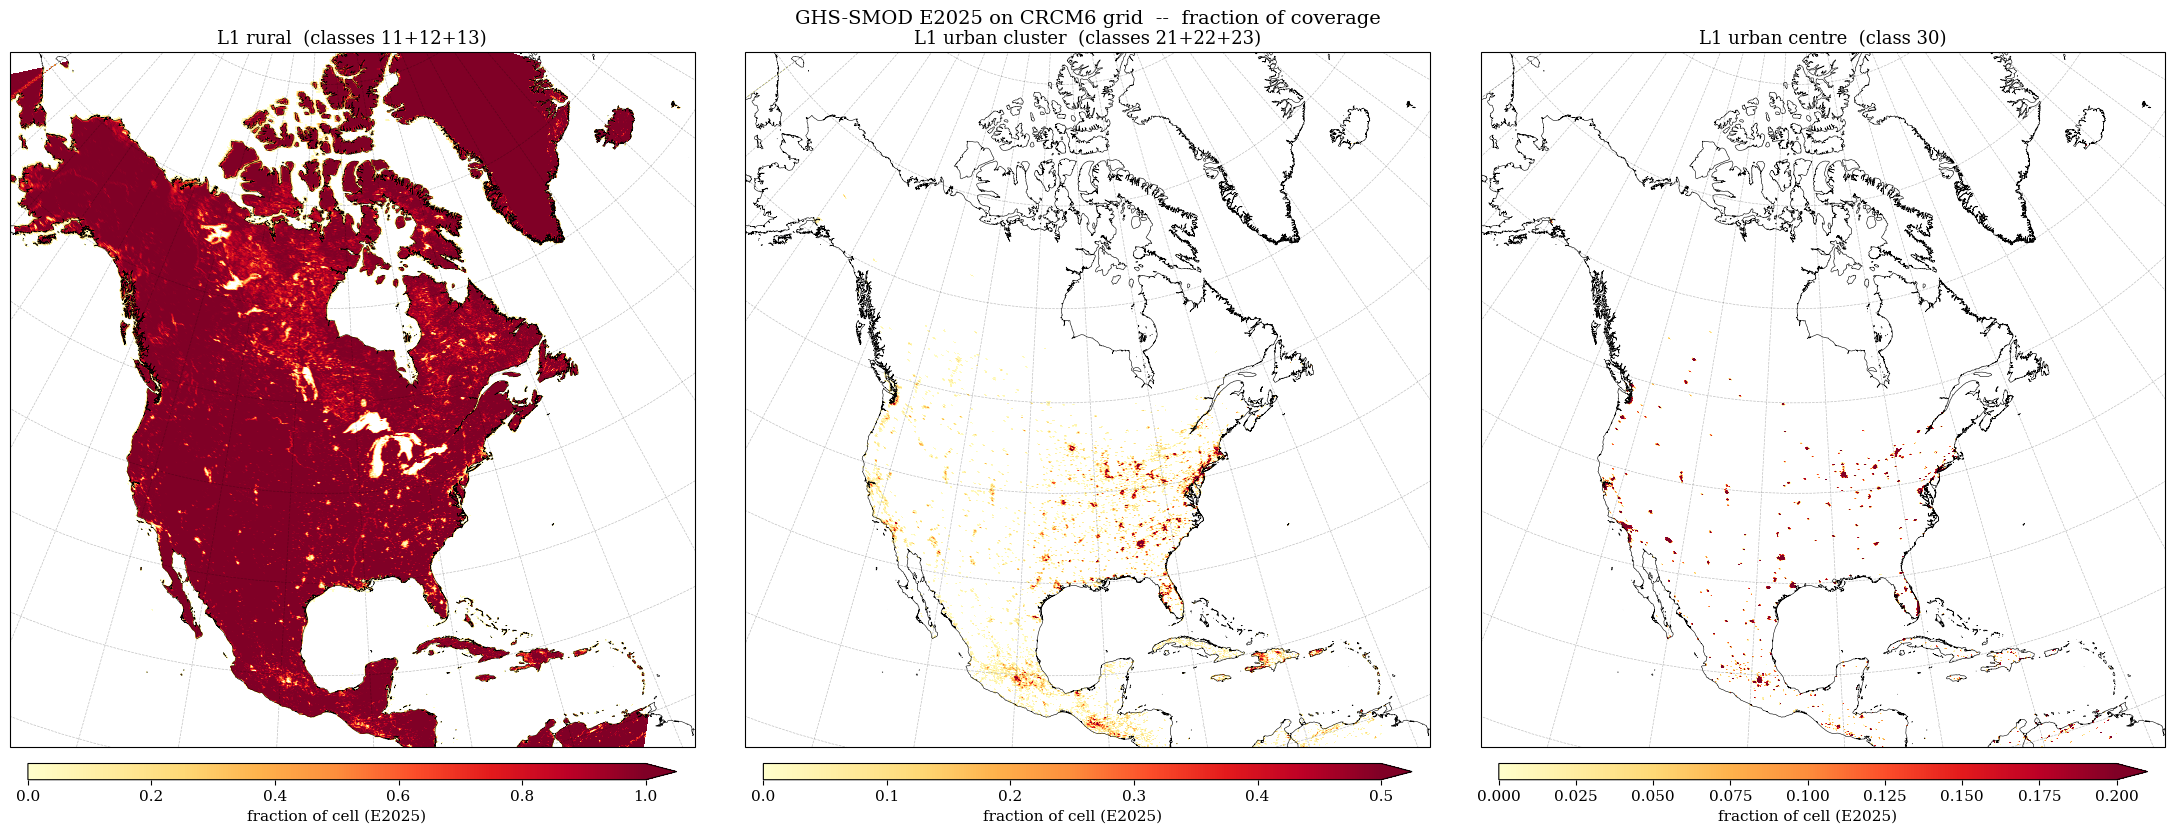

In [4]:
L1_GROUPS = ['L1_rural', 'L1_urban_cluster', 'L1_urban_centre']
L1_TITLES = {
    'L1_rural':         'L1 rural  (classes 11+12+13)',
    'L1_urban_cluster': 'L1 urban cluster  (classes 21+22+23)',
    'L1_urban_centre':  'L1 urban centre  (class 30)',
}
# Per-group colour scale picked from observed value ranges.
L1_VMAX = {'L1_rural': 1.0, 'L1_urban_cluster': 0.5, 'L1_urban_centre': 0.2}

fig, axes = plt.subplots(1, 3, subplot_kw={'projection': PLOTCRS},
                          figsize=(22, 8), constrained_layout=True)

for ax, grp in zip(axes, L1_GROUPS):
    make_basemap_ax(ax)
    field = ds[f'frac_{grp}'].where(ds[f'frac_{grp}'] > 0)
    im = plot_field(ax, field, cmap='YlOrRd',
                     norm=mcolors.Normalize(vmin=0.0, vmax=L1_VMAX[grp]))
    ax.set_title(L1_TITLES[grp], fontsize=13)
    cb = fig.colorbar(im, ax=ax, orientation='horizontal',
                       pad=0.02, aspect=40, shrink=0.9, extend='max')
    cb.set_label('fraction of cell (E2025)', fontsize=11)

fig.suptitle('GHS-SMOD E2025 on CRCM6 grid  --  fraction of coverage',
              fontsize=14, y=1.02)

## 2. Binary masks: fraction > threshold

For storm-impact metrics we need a **binary** keep/discard decision per cell.
The final mask depends on two choices:

- **Which L1 group(s)** to include (rural / urban_cluster / urban_centre).
- **Which fraction threshold** to apply on top (e.g. "keep cell if at least 10%
  of its area is urban cluster").

The 3x3 grid below scans both axes simultaneously. Each column is a threshold;
each row is an L1 group. Darker cells are kept by the mask, lighter cells are
discarded.

Reading guide:
- Move **right** to see what a stricter threshold removes (typically small
  isolated towns).
- Move **down** to switch to a more restrictive population definition
  (rural -> cluster -> centre).

The threshold values chosen (1%, 10%, 50%) span the range from "any human
presence at all" to "majority of the cell is that class".

Text(0.5, 1.01, 'Binary DEGURBA masks for combinations of L1 group x fraction threshold (E2025)')

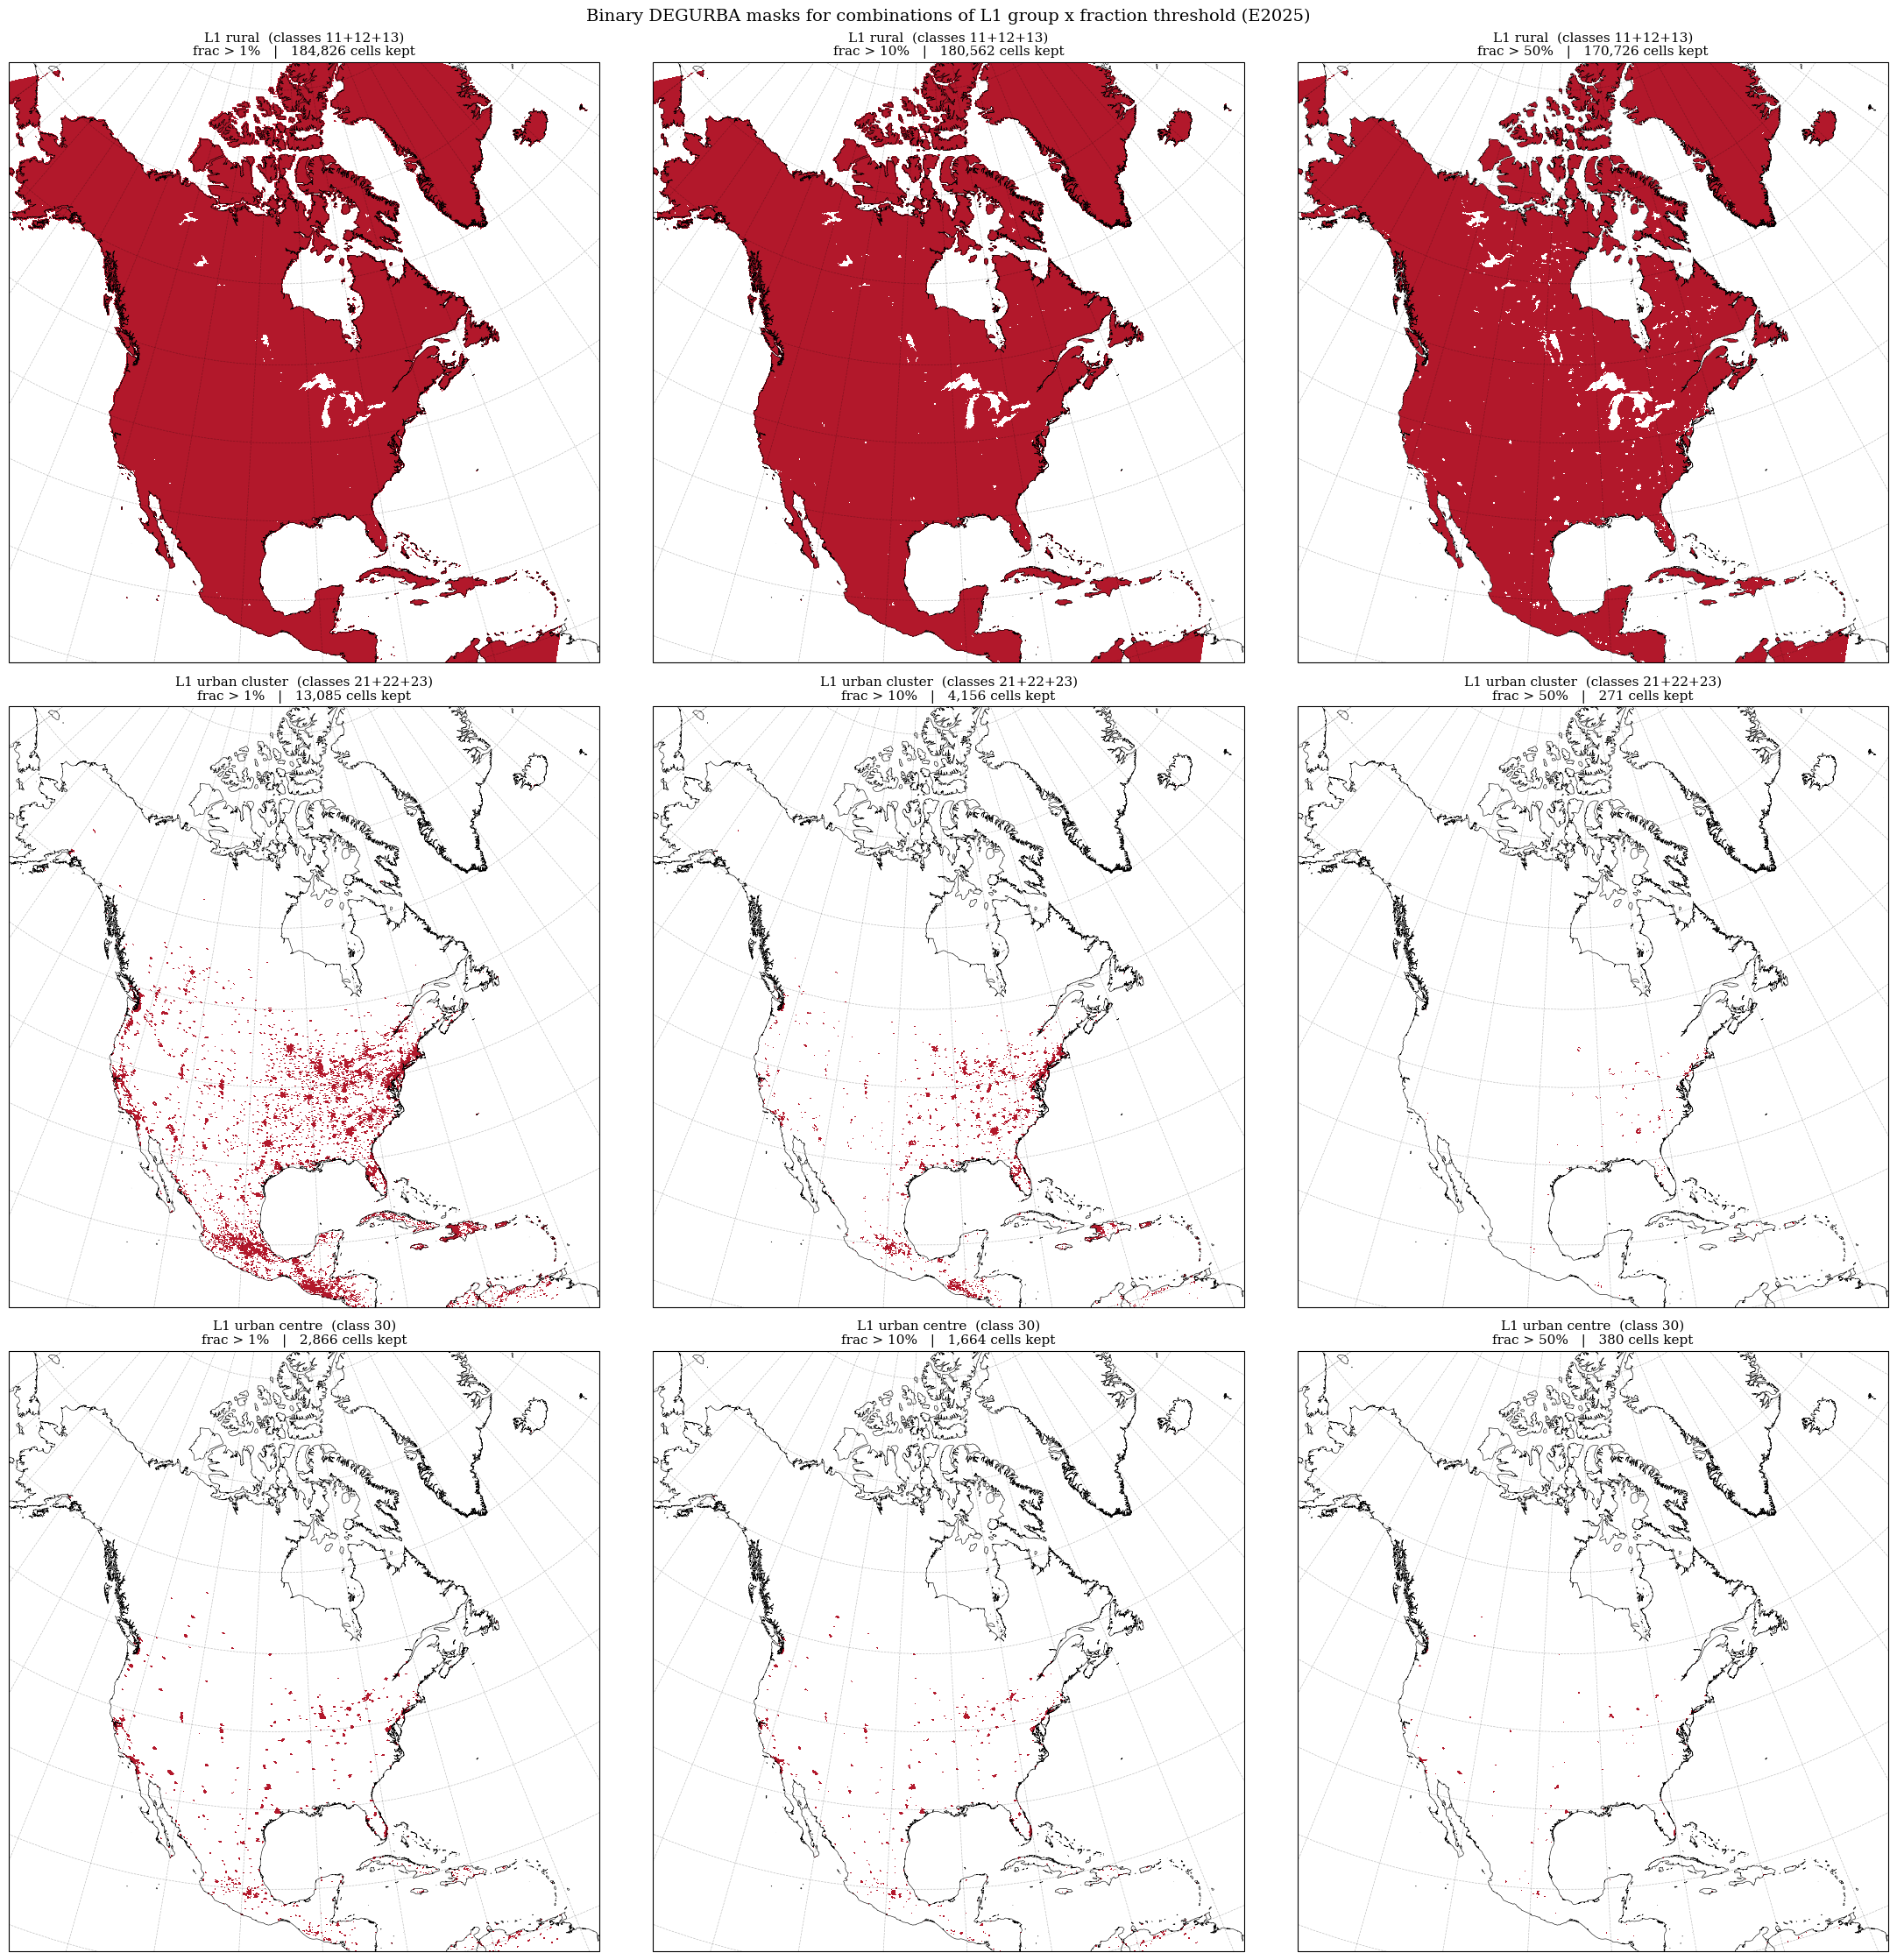

In [5]:
THRESHOLDS = [0.01, 0.10, 0.50]

fig, axes = plt.subplots(len(L1_GROUPS), len(THRESHOLDS),
                          subplot_kw={'projection': PLOTCRS},
                          figsize=(22, 22), constrained_layout=True)

# A binary colormap that draws kept cells in opaque red, discarded/zero cells
# as transparent (so the basemap shows through).
BIN_CMAP = mcolors.ListedColormap(['#0000ff00', '#b2182b'])  # (alpha=0) / dark red
BIN_NORM = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], ncolors=2)

for i, grp in enumerate(L1_GROUPS):
    frac = ds[f'frac_{grp}'].values
    for j, thr in enumerate(THRESHOLDS):
        ax = axes[i, j]
        make_basemap_ax(ax)
        mask = (frac > thr).astype(np.int8)
        n_kept = int(mask.sum())
        plot_field(ax, mask, cmap=BIN_CMAP, norm=BIN_NORM)
        ax.set_title(
            f'{L1_TITLES[grp]}\nfrac > {thr:.0%}   |   {n_kept:,} cells kept',
            fontsize=11,
        )

fig.suptitle('Binary DEGURBA masks for combinations of L1 group x fraction threshold (E2025)',
              fontsize=14, y=1.01)

## 3. A combined "populated land" mask

A common choice in impact studies is to treat *anywhere people live* as the
relevant mask, i.e. the union of urban cluster + urban centre (DEGURBA L1
codes 20 and 30 combined, or equivalently L2 codes >= 21).

This avoids the ambiguity of choosing between "large cities only" vs "towns
too", and lines up with the JRC/EU convention used in most climate-risk
assessments (e.g. Formetta & Feyen 2019, UNDRR reports).

If we later prefer a stricter mask, we simply raise the fraction threshold
and/or switch to `L1_urban_centre` alone. The figure below shows that this
combined mask with a 10% threshold picks up the populated east coast, the
Pacific NW corridor, the Great Lakes belt and major metropolitan areas,
while dropping lightly-populated interior regions and northern Canada.

Text(0.5, 1.02, 'Combined "populated land" mask at several fraction thresholds (E2025)')

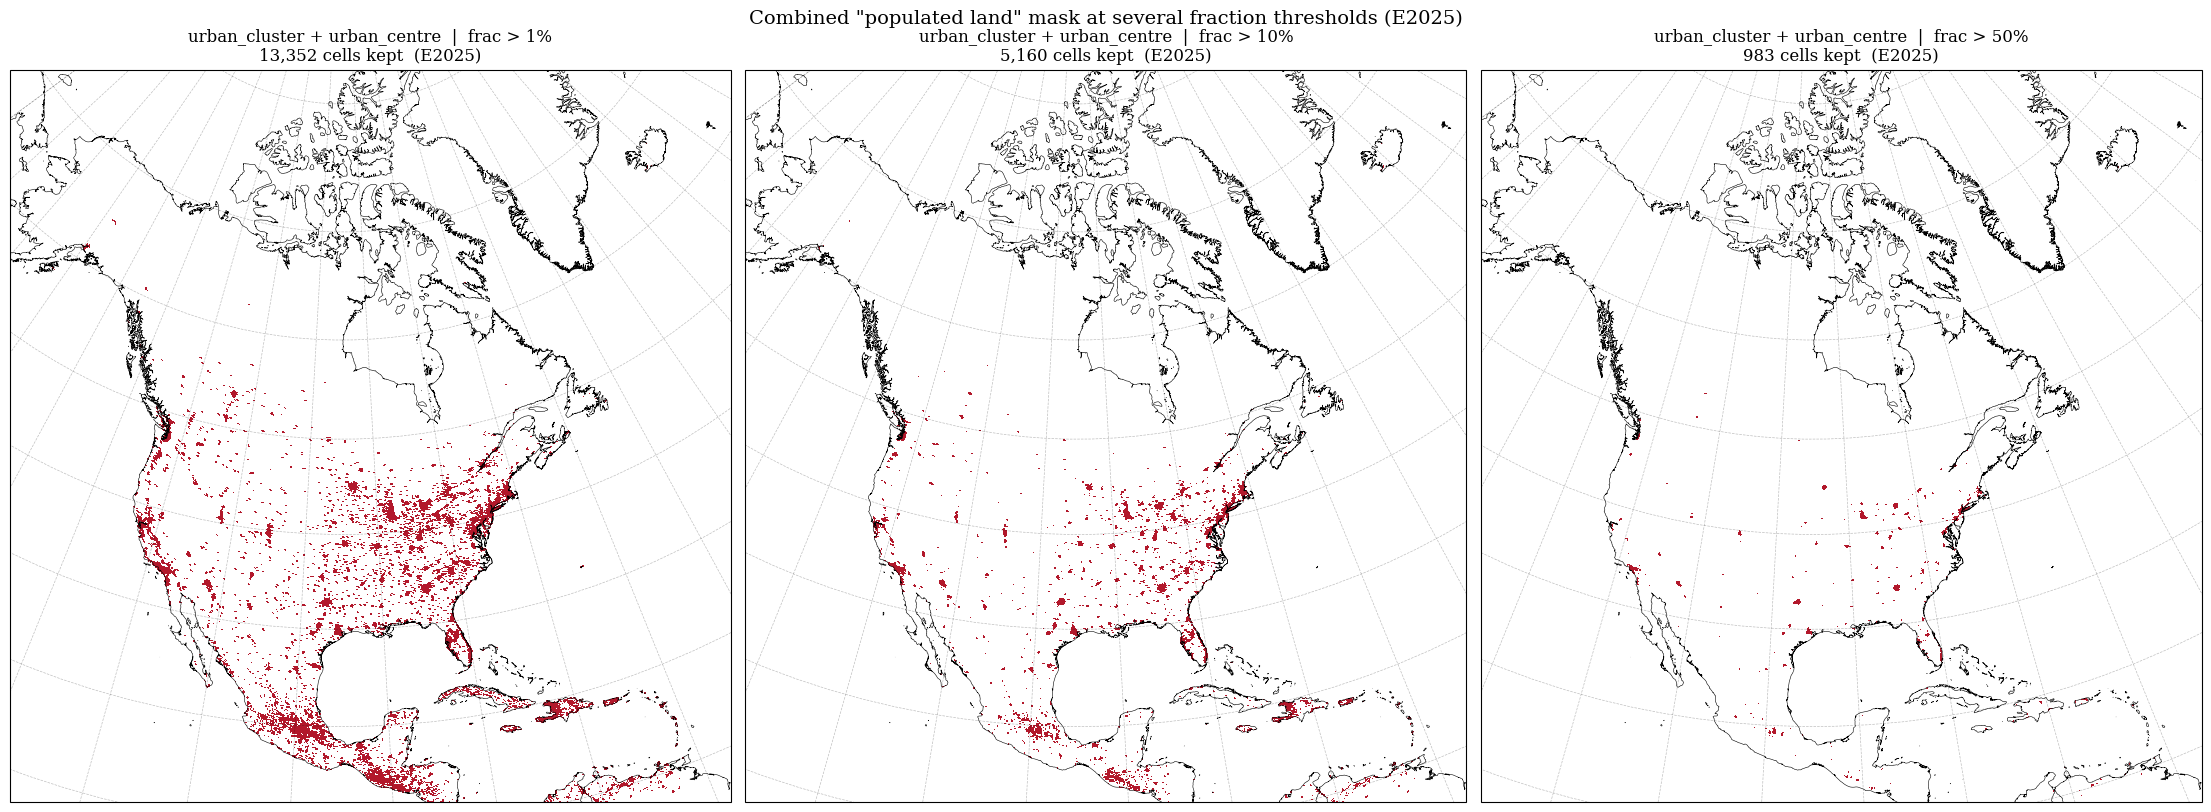

In [6]:
# Combined populated mask = urban_cluster + urban_centre (= L2 codes >= 21)
pop_frac = (ds['frac_L1_urban_cluster'] + ds['frac_L1_urban_centre']).values

fig, axes = plt.subplots(1, len(THRESHOLDS), subplot_kw={'projection': PLOTCRS},
                          figsize=(22, 8), constrained_layout=True)

for ax, thr in zip(axes, THRESHOLDS):
    make_basemap_ax(ax)
    mask = (pop_frac > thr).astype(np.int8)
    plot_field(ax, mask, cmap=BIN_CMAP, norm=BIN_NORM)
    ax.set_title(
        f'urban_cluster + urban_centre  |  frac > {thr:.0%}\n'
        f'{int(mask.sum()):,} cells kept  (E2025)', fontsize=12,
    )

fig.suptitle('Combined "populated land" mask at several fraction thresholds (E2025)',
              fontsize=14, y=1.02)

## 4. Article figure: urban mask used in `storm_percentile_metrics.py`

This is the figure intended for the article. It shows the binary urban mask
actually applied in `storm_percentile_metrics.py` before counting per-storm
exceedances:

$$\bigl(\mathrm{frac}_{L1\_\mathrm{urban\_cluster}} +
        \mathrm{frac}_{L1\_\mathrm{urban\_centre}}\bigr) > 0
\quad\mathrm{AND}\quad
\mathrm{lat} > 30^{\circ}\mathrm{N}$$

A single fixed E2025 SMOD mask is used for both historical and future
simulations, so this map is also the mask of the future runs. Cartographic
context (states, borders, rivers, lakes, coastlines) is included to ease
geographic reading; no shaded-relief background is used so that the
urbanized cells remain visually prominent.

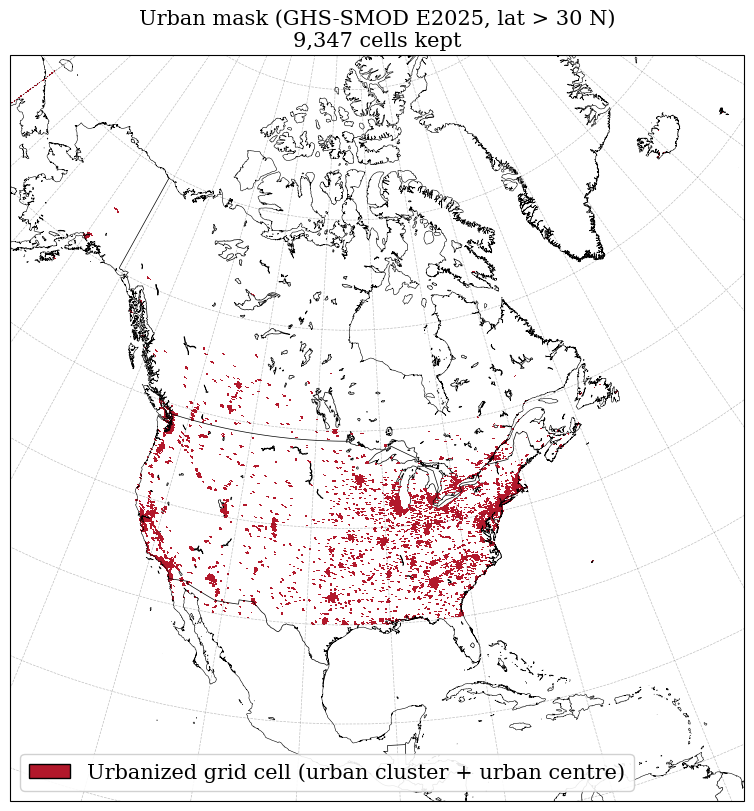

In [21]:
# ---------------------------------------------------------------------------
# Article figure: urban mask actually applied in storm_percentile_metrics.py.
#
# Mask definition (matches storm_percentile_metrics.py:load_spatial_mask):
#     (frac_L1_urban_cluster + frac_L1_urban_centre) > 0   AND   lat > 30 N
#
# Cartographic context (states, borders, lakes, rivers, coastlines) is added
# directly to the axes, without the NE1 shaded-relief background, so that
# the binary urban dots remain the visual focus of the figure.
# ---------------------------------------------------------------------------
from matplotlib.patches import Patch

# Build the mask exactly as storm_percentile_metrics.py does
urban_mask = ((ds['frac_L1_urban_cluster'] + ds['frac_L1_urban_centre']) > 0).values
urban_mask = (urban_mask & (lat2d > 30.0)).astype(np.int8)
n_kept = int(urban_mask.sum())

# Natural-Earth assets (50m scale, same style as plot_storm_percentile_metrics_30N_urban.ipynb)
borders = cartopy.feature.NaturalEarthFeature(
    category='cultural', name='admin_0_boundary_lines_land',
    scale='50m', facecolor='none')
states = cartopy.feature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces',
    scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(
    category='physical', name='lakes',
    scale='50m', facecolor='none')
rivers = cartopy.feature.NaturalEarthFeature(
    category='physical', name='rivers_lake_centerlines',
    scale='50m', facecolor='none')

fig, ax = plt.subplots(subplot_kw={'projection': PLOTCRS},
                       figsize=(10, 8), constrained_layout=True)
ax.set_extent(PLOT_EXTENT, crs=ccrs.PlateCarree())

# Cartographic context (no shaded-relief imshow; clean white background)
ax.add_feature(lakes,  zorder=1, edgecolor='black', linewidth=0.5)
# ax.add_feature(rivers, zorder=1, edgecolor='black', linewidth=0.1)
# ax.add_feature(states, zorder=2, edgecolor='black', linewidth=0.3)
ax.add_feature(borders, zorder=3, edgecolor='black', linewidth=0.5)
ax.coastlines(resolution='10m', linewidth=0.4, color='black', zorder=3)
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25,
             xlocs=range(-180, 181, 10), ylocs=range(-90, 91, 10))

# Urban mask on top
plot_field(ax, urban_mask, cmap=BIN_CMAP, norm=BIN_NORM)

ax.set_title(f'Urban mask '
             f'(GHS-SMOD E2025, lat > 30 N)\n'
             f'{n_kept:,} cells kept', fontsize=15)

# Small legend explaining the red points
legend_elements = [
    Patch(facecolor='#b2182b', edgecolor='black',
          label='Urbanized grid cell (urban cluster + urban centre)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=15,
          framealpha=0.9, edgecolor='#cccccc')

fig.savefig(f'/project/rrg-gachon/vdemeyer/ALL/PLOT/supp_urban_mask.png', dpi=300, bbox_inches='tight')